In [1]:
import geopandas
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import shapely
from shapely.geometry import Polygon
import pandas as pd

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
    "font.size" : 10,
    "figure.dpi" : 300
})

split_order = ['Treino', 'Validação', 'Teste']
split_palette = {'Treino':'b', 'Validação':'g', 'Teste':'r'}

def get_figsize(fig_ratio=1/2.414, text_width_ratio=1, orientation='landscape'):
    text_width = 210 - 30 - 20 # A4 - bordas
    width_inch = (text_width * text_width_ratio) / 25.4
    if orientation == 'landscape':
        height_inch = width_inch * fig_ratio
    elif orientation == 'portrait':
        height_inch = width_inch * fig_ratio
    else:
        raise ValueError("orientation must be 'landscape' or 'portrait'") 
        
    return width_inch, height_inch



%matplotlib notebook

In [11]:
info_file = './dados/survey_info.csv'

survey_info = pd.read_csv(info_file, sep='\t')

world = geopandas.read_file(geopandas.datasets.get_path("naturalearth_lowres"))
america = world[world.continent.str.contains('America')]

polys = []
for _, row in survey_info.iterrows():
    minx = row.eastLong
    miny = row.southLat
    maxx = row.westLong
    maxy = row.northLat
    polys.append(shapely.geometry.box(minx, miny, maxx, maxy))
    
survey_bboxes = geopandas.GeoDataFrame(survey_info, geometry=polys, crs=america.crs)

light_grey = np.array([0.95,0.95,0.95])

def plot_map(gdf, save_file=None, column_color='area', america_color=light_grey, 
             figsize=(8, 6), show_legend=True, alpha=0.5, cmap='viridis'):
    fig, ax1 = plt.subplots(1, 1, figsize=figsize)
    if show_legend and column_color == 'split':
        handles = [Line2D([],[], linewidth=0, marker='o', markeredgewidth=0, markersize=10,
                          color=split_palette[s], alpha=alpha, label=s) for s in split_order]
        ax1.legend(handles=handles, loc='lower left')
        show_legend = False
    
    america.plot(ax=ax1, color=america_color, edgecolor='gray')
    gdf.plot(column_color, ax=ax1, cax=ax1, alpha=alpha, cmap=cmap, marker='s',
                  legend=show_legend, legend_kwds={'loc':'lower left'})
    ax1.set_axis_off()
    plt.tight_layout()
    
    if not save_file:
        plt.show()
    else:
        plt.savefig(save_file)
        print("Salvo arquivo", save_file)

<IPython.core.display.Javascript object>


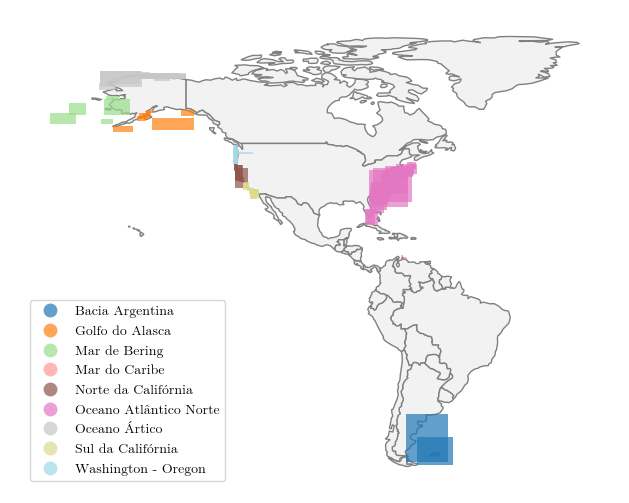

In [9]:
save_file = None
save_file = './figuras/survey_area_map.pdf'
figsize = get_figsize(fig_ratio=0.8, orientation='portrait')

plot_map(survey_bboxes, save_file, 'area', figsize=figsize, alpha=0.7, cmap='tab20')

<IPython.core.display.Javascript object>


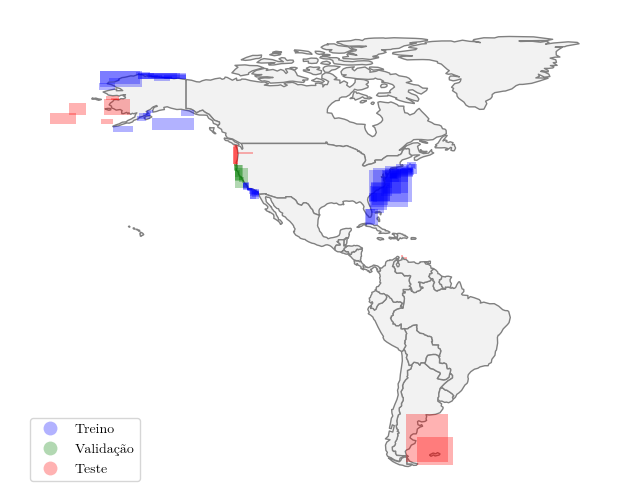

Salvo arquivo ./figuras/survey_split_map.pdf


In [12]:
save_file = None
save_file = './figuras/survey_split_map.pdf'
figsize = get_figsize(fig_ratio=0.8, orientation='portrait')

from matplotlib import colors
split_colors = [colors.to_rgb(c) for c in 'rbg']
split_cmap = colors.ListedColormap(np.array(split_colors))
plot_map(survey_bboxes, save_file, column_color='split', figsize=figsize, cmap=split_cmap, alpha=0.3)

In [ ]:
# Tabela: tamanho de cada conjunto
split_size = survey_info.groupby('split')['clean_size'].sum()

for s in split_order:
    print("{}\t{:.1f} GB".format(s, split_size[s]/1000))

In [ ]:
# Tabela: tamanho e split de cada área
group = survey_info.groupby('area')
area_info = group.agg({'split' : 'unique', 'clean_size' : 'sum'})
for _, row in area_info.iterrows():
    #print(row.name, row.split[0], "{:.2f} GB".format(row.clean_size/1000))
    print(row.name, row.split[0], "{:.0f} MB".format(row.clean_size), sep='\t')

In [ ]:
group = survey_bboxes.groupby('suffix')
print(group.agg({'suffix' : 'count', 'clean_size' : 'sum'}))